# Phase 8: a different family, and why it did not help

Phase 7 found that averaging models pays in proportion to how much they disagree, and that two CoAtNets by the same
author disagree only a little (correlation 0.94-0.96, worth +0.005 on the hidden test). The public stack's larger
gains come from other families, above all DINOv2. This notebook adds one.

The arm is built the Phase 6 way: a Kaggle job encodes the same 64-slice stacks with a **frozen** DINOv2-small
(windows at 336 px, features = CLS token plus mean patch token, 768 dimensions), and an attention head trains on
those features locally. Nothing is fine-tuned.

The result is a negative one, and it sharpens the rule from Phase 7.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
import evaluation as ev
import head_training as ht
import plot_style as ps
import raptor_core as rc

ps.apply()
pd.set_option("display.precision", 4)
sig = lambda x: 1 / (1 + np.exp(-x))
logit = lambda p: np.log(p / (1 - p))


def load_shards(folder, feat, ids):
    F = np.concatenate([np.load(ROOT / folder / feat.format(k)) for k in (0, 1)])
    I = np.concatenate([np.load(ROOT / folder / ids.format(k)) for k in (0, 1)]).astype(str)
    return F, {s: i for i, s in enumerate(I)}


Xd, row_d = load_shards("outputs/kaggle/dino_feats", "dino_feats_shard{}.npy", "dino_ids_shard{}.npy")
Xc, row_c = load_shards("outputs/kaggle/train_feats", "feats_shard{}.npy", "ids_shard{}.npy")
soft = pd.read_csv(ROOT / "data/soft_labels/labels_llm_soft.csv")
soft["StudyInstanceUID"] = soft.StudyInstanceUID.astype(str)
gold = pd.read_csv(ROOT / "outputs/kaggle/gold_run/gold_labels.csv")
gold["StudyInstanceUID"] = gold.StudyInstanceUID.astype(str)
Y = gold[rc.LAB].values.astype(int)

train_d = np.array([row_d[s] for s in soft.StudyInstanceUID]); train_c = np.array([row_c[s] for s in soft.StudyInstanceUID])
gold_d = np.array([row_d[s] for s in gold.StudyInstanceUID]); gold_c = np.array([row_c[s] for s in gold.StudyInstanceUID])
split = np.random.default_rng(2646).permutation(len(train_d))
val = split[:int(0.15 * len(train_d))]                       # the same held-out studies as Phase 6
S = soft[rc.LAB].values


def heads(folder, name, dim, seeds=3):
    out = []
    for s in range(seeds):
        h = ht.AttentionHead(f_dim=dim)
        h.load_state_dict(torch.load(ROOT / folder / f"{name}_seed{s}.pt"))
        out.append(h.eval())
    return out


def predict(hs, X):
    return sig(np.mean([ht.predict(h, X) for h in hs], axis=0))


dino = heads("outputs/local/heads_dino", "D_mask_unsure", 768)
checkpoint, _ = rc.load_checkpoint(str(ROOT / "models/raptor_ft_coatnet_v10_full.pt"), "cpu")
coatnet = [ht.AttentionHead.from_checkpoint(checkpoint).eval()]

## 1. How good is it, and how different?

In [2]:
def macro(y, p):
    return np.mean([ev.auc(y[:, j], p[:, j]) for j in range(len(rc.LAB)) if 0 < y[:, j].sum() < len(y)])


def mean_corr(pa, pb):
    la, lb = logit(pa), logit(pb)
    return np.mean([np.corrcoef(la[:, j], lb[:, j])[0, 1] for j in range(len(rc.LAB))])


gold_dino, gold_coat = predict(dino, Xd[gold_d]), predict(coatnet, Xc[gold_c])
all_dino, all_coat = predict(dino, Xd), predict(coatnet, Xc)
summary = pd.DataFrame([
    {"model": "CoAtNet v10 (the checkpoint)", "gold macro-AUC": rc.macro_auc(Y, gold_coat)[0],
     "correlation with the CoAtNet": 1.0},
    {"model": "DINOv2 head on frozen features", "gold macro-AUC": rc.macro_auc(Y, gold_dino)[0],
     "correlation with the CoAtNet": mean_corr(all_dino, all_coat)},
]).set_index("model")
print(f"for comparison, the other CoAtNets correlate 0.94-0.96 with v10 (Phase 7)")
summary

for comparison, the other CoAtNets correlate 0.94-0.96 with v10 (Phase 7)


,gold macro-AUC,correlation with the CoAtNet
model,,
CoAtNet v10 (the checkpoint),0.9170,1.0000
DINOv2 head on frozen features,0.7683,0.6803


The DINOv2 arm is exactly as different as hoped: correlation 0.65-0.68 against 0.94-0.96 between CoAtNets. It is
also 0.15 AUC weaker, because nothing about DINOv2 was trained on knees: only the 280 k-parameter head was.

## 2. What weight does it deserve?

Chosen on the 652 held-out training studies, never on the 58 gold ones. Their soft labels are thresholded at 0.5 to
score an AUC.

weight chosen on validation: 0.00

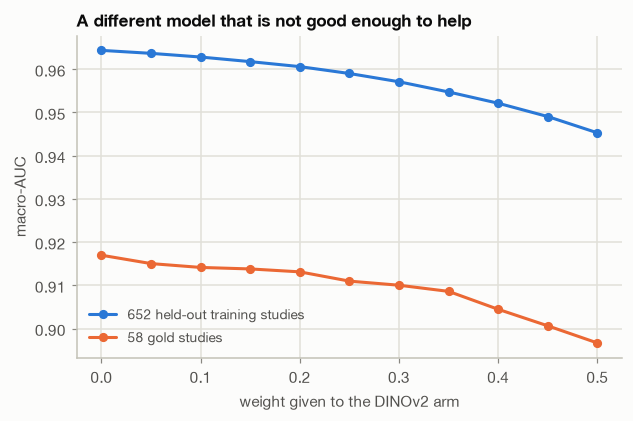

,weight on DINOv2,validation macro-AUC,gold macro-AUC
0,0.00,0.9644,0.9170
1,0.05,0.9637,0.9150
2,0.10,0.9628,0.9141
3,0.15,0.9618,0.9138
4,0.20,0.9606,0.9131
5,0.25,0.9590,0.9110
6,0.30,0.9571,0.9100
7,0.35,0.9547,0.9086
8,0.40,0.9521,0.9045
9,0.45,0.9491,0.9006


In [3]:
y_val = (S[val] >= 0.5).astype(int)
val_dino, val_coat = predict(dino, Xd[train_d[val]]), predict(coatnet, Xc[train_c[val]])
weights = np.arange(0, 0.55, 0.05)
curve = pd.DataFrame({
    "weight on DINOv2": weights,
    "validation macro-AUC": [macro(y_val, (1 - w) * val_coat + w * val_dino) for w in weights],
    "gold macro-AUC": [rc.macro_auc(Y, (1 - w) * gold_coat + w * gold_dino)[0] for w in weights],
})
chosen = curve.loc[curve["validation macro-AUC"].idxmax(), "weight on DINOv2"]
print(f"weight chosen on validation: {chosen:.2f}")

fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.plot(curve["weight on DINOv2"], curve["validation macro-AUC"], color=ps.BLUE, marker="o", markersize=5,
        label="652 held-out training studies")
ax.plot(curve["weight on DINOv2"], curve["gold macro-AUC"], color=ps.ORANGE, marker="o", markersize=5,
        label="58 gold studies")
ax.set_xlabel("weight given to the DINOv2 arm")
ax.set_ylabel("macro-AUC")
ax.set_title("A different model that is not good enough to help")
ax.legend(loc="lower left", fontsize=9)
fig.savefig(ROOT / "outputs/figures/phase8_weight.png")
plt.show()
curve

Every weight above zero makes the blend worse, on both sets, so the honest choice is to leave the arm out.

**The rule from Phase 7 needs its second half.** Averaging pays when models disagree *and* are comparably good. Our
DINOv2 arm has the disagreement (0.65) but gives up 0.15 AUC, and a member that far behind drags the average down
faster than its independence lifts it. The CoAtNets are the mirror image: close in strength, too alike to help much.

The public stack gets both at once. Its DINOv2 members are **fine-tuned** on this data, with the last transformer
blocks unfrozen, so they are both different and strong, and it gives that branch 40-60% of the weight per finding.
Reproducing that means training a vision transformer on the competition data, not training a head on frozen features:
hours of GPU per fold rather than seconds.

## 3. Summary

| Question | Answer |
|---|---|
| Is a frozen DINOv2 arm different from the CoAtNet? | Yes: score correlation 0.65-0.68, against 0.94-0.96 between CoAtNets |
| Is it any good on its own? | No: 0.768 macro-AUC on gold against 0.917 |
| Does adding it help? | No: every weight above zero loses, on validation and on gold |
| What would it take? | Fine-tuning the transformer on this data, which is what the public stack's 20 DINOv2 members do |

Phases 7 and 8 together bound the problem. Same family, similar strength: +0.005. Different family, much weaker:
nothing. The public stack's remaining +0.009 needs models that are different *and* trained on these knees.